In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, fbeta_score, roc_auc_score, roc_curve, 
                            confusion_matrix, classification_report)

# Setting aesthetic style for plots
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports loaded successfully!")

Imports loaded successfully!


In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')

print("="*60)
print("1. DATA UNDERSTANDING")
print("="*60)
print(f"Shape: {df.shape} | Records: {df.shape[0]} | Attributes: {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

1. DATA UNDERSTANDING
Shape: (1000, 9) | Records: 1000 | Attributes: 9

Data Types:
Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

First 5 rows:
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0              

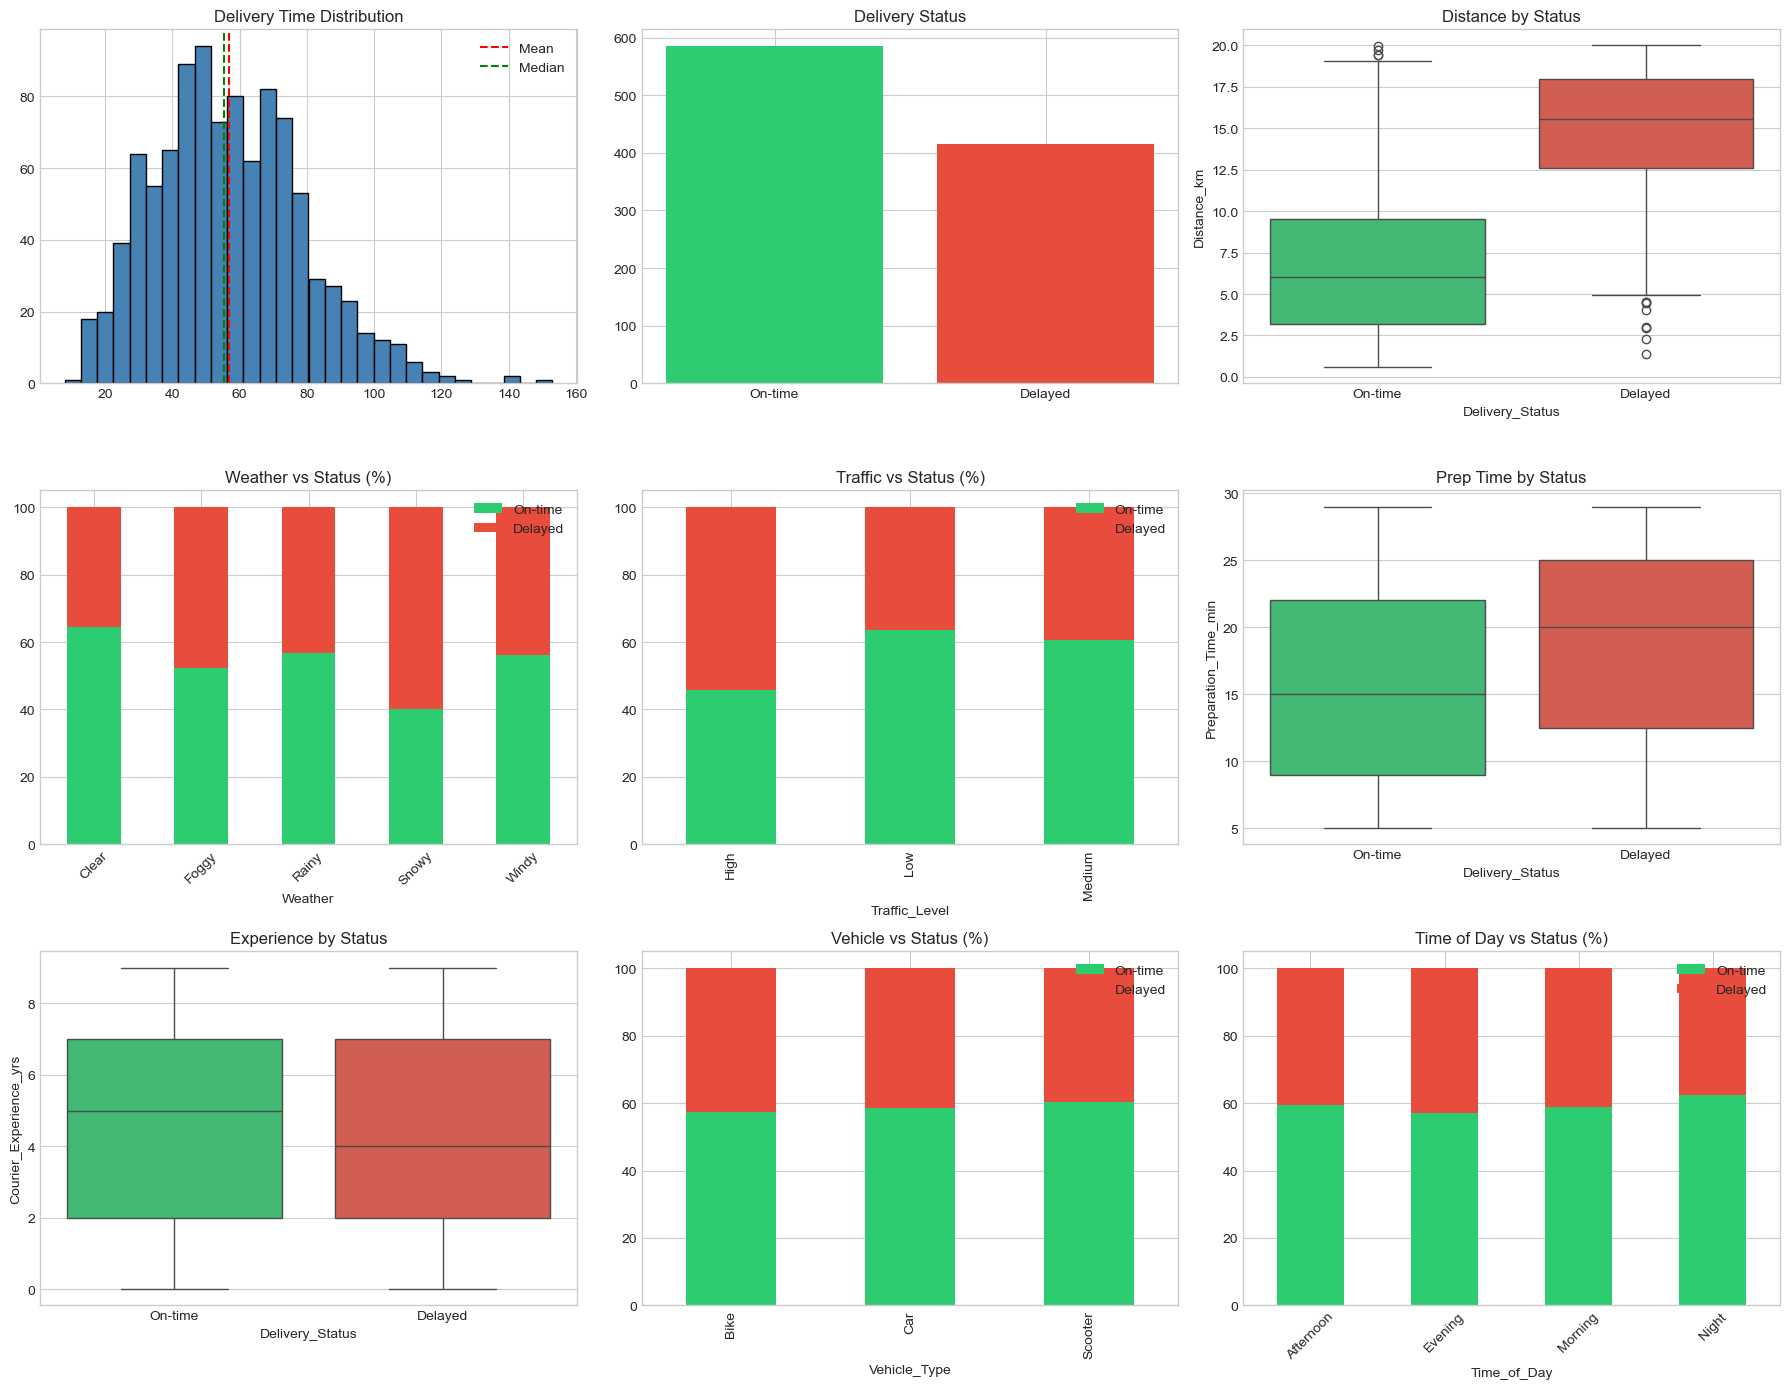

In [3]:
df['Delivery_Status'] = (df['Delivery_Time_min'] > 60).astype(int)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# 1. Target distribution
axes[0,0].hist(df['Delivery_Time_min'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].axvline(df['Delivery_Time_min'].mean(), color='red', linestyle='--', label='Mean')
axes[0,0].axvline(df['Delivery_Time_min'].median(), color='green', linestyle='--', label='Median')
axes[0,0].set_title('Delivery Time Distribution')
axes[0,0].legend()

# 2. Binary target
axes[0,1].bar(['On-time','Delayed'], df['Delivery_Status'].value_counts(), color=['#2ecc71','#e74c3c'])
axes[0,1].set_title('Delivery Status')

# 3. Distance by status
sns.boxplot(x='Delivery_Status', y='Distance_km', data=df, ax=axes[0,2], palette=['#2ecc71','#e74c3c'])
axes[0,2].set_xticklabels(['On-time','Delayed'])
axes[0,2].set_title('Distance by Status')

# 4. Weather vs Status
weather_pct = pd.crosstab(df['Weather'], df['Delivery_Status'], normalize='index')*100
weather_pct.plot(kind='bar', stacked=True, ax=axes[1,0], color=['#2ecc71','#e74c3c'])
axes[1,0].set_title('Weather vs Status (%)')
axes[1,0].legend(['On-time','Delayed'])
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Traffic vs Status
traffic_pct = pd.crosstab(df['Traffic_Level'], df['Delivery_Status'], normalize='index')*100
traffic_pct.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Traffic vs Status (%)')
axes[1,1].legend(['On-time','Delayed'])

# 6. Prep time by status
sns.boxplot(x='Delivery_Status', y='Preparation_Time_min', data=df, ax=axes[1,2], palette=['#2ecc71','#e74c3c'])
axes[1,2].set_xticklabels(['On-time','Delayed'])
axes[1,2].set_title('Prep Time by Status')

# 7. Experience by status
sns.boxplot(x='Delivery_Status', y='Courier_Experience_yrs', data=df, ax=axes[2,0], palette=['#2ecc71','#e74c3c'])
axes[2,0].set_xticklabels(['On-time','Delayed'])
axes[2,0].set_title('Experience by Status')

# 8. Vehicle vs Status
vehicle_pct = pd.crosstab(df['Vehicle_Type'], df['Delivery_Status'], normalize='index')*100
vehicle_pct.plot(kind='bar', stacked=True, ax=axes[2,1], color=['#2ecc71','#e74c3c'])
axes[2,1].set_title('Vehicle vs Status (%)')
axes[2,1].legend(['On-time','Delayed'])

# 9. Time of Day vs Status
time_pct = pd.crosstab(df['Time_of_Day'], df['Delivery_Status'], normalize='index')*100
time_pct.plot(kind='bar', stacked=True, ax=axes[2,2], color=['#2ecc71','#e74c3c'])
axes[2,2].set_title('Time of Day vs Status (%)')
axes[2,2].legend(['On-time','Delayed'])
axes[2,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('EDA_Overview.png', dpi=300, bbox_inches='tight')
plt.show()

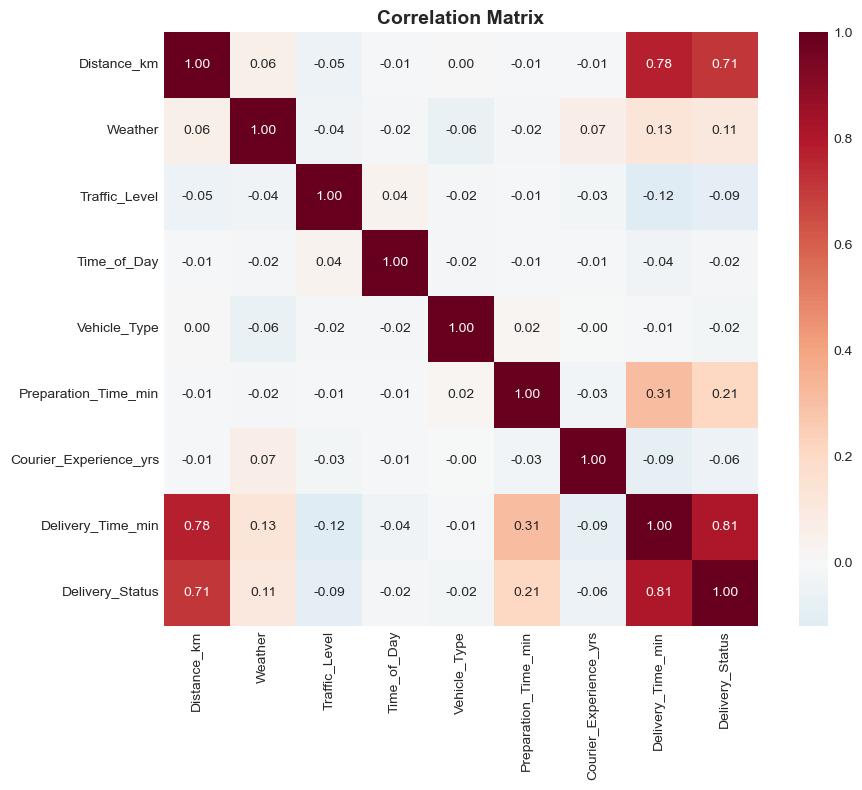

Correlation with Delivery_Status:
Delivery_Time_min         0.808069
Distance_km               0.712507
Preparation_Time_min      0.211797
Weather                   0.108853
Traffic_Level            -0.093368
Courier_Experience_yrs   -0.060356
Vehicle_Type             -0.024568
Time_of_Day              -0.019180
Name: Delivery_Status, dtype: float64

T-Tests:
Distance_km: p=0.000000
Preparation_Time_min: p=0.000000
Courier_Experience_yrs: p=0.060237

Chi-Square Tests:
Weather: p=0.000181
Traffic_Level: p=0.000108
Time_of_Day: p=0.826821
Vehicle_Type: p=0.735749


In [4]:
df_corr = df.copy()
for col in ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']:
    df_corr[col] = df_corr[col].astype('category').cat.codes

corr_matrix = df_corr[['Distance_km','Weather','Traffic_Level','Time_of_Day',
                       'Vehicle_Type','Preparation_Time_min','Courier_Experience_yrs',
                       'Delivery_Time_min','Delivery_Status']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True, fmt='.2f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Correlation_Matrix.png', dpi=300)
plt.show()

print("Correlation with Delivery_Status:")
print(corr_matrix['Delivery_Status'].drop('Delivery_Status').sort_values(key=abs, ascending=False))

# Statistical tests
from scipy.stats import ttest_ind, chi2_contingency
print("\nT-Tests:")
ontime = df[df['Delivery_Status']==0]
delayed = df[df['Delivery_Status']==1]
for col in ['Distance_km','Preparation_Time_min','Courier_Experience_yrs']:
    _, p = ttest_ind(ontime[col].dropna(), delayed[col].dropna())
    print(f"{col}: p={p:.6f}")

print("\nChi-Square Tests:")
for col in ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']:
    _, p, _, _ = chi2_contingency(pd.crosstab(df[col], df['Delivery_Status']))
    print(f"{col}: p={p:.6f}")

In [5]:
print("\n" + "="*60)
print("2. DATA PREPROCESSING")
print("="*60)

# Missing values
df['Weather'].fillna(df['Weather'].mode()[0], inplace=True)
df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0], inplace=True)
df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0], inplace=True)
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)
print("Missing values treated.")

# Feature Engineering
df['Distance_per_Experience'] = df['Distance_km'] / (df['Courier_Experience_yrs'] + 1)
df['Total_Load_Score'] = (df['Distance_km']*0.5 + df['Preparation_Time_min']*0.3 + df['Courier_Experience_yrs']*0.2)
weather_map = {'Clear':1,'Windy':2,'Foggy':3,'Rainy':4,'Snowy':5}
traffic_map = {'Low':1,'Medium':2,'High':3}
df['Weather_Severity'] = df['Weather'].map(weather_map)
df['Traffic_Severity'] = df['Traffic_Level'].map(traffic_map)
df['Environmental_Stress'] = df['Weather_Severity'] * df['Traffic_Severity']
print("Features engineered.")

# Outlier capping
df['Delivery_Time_min'] = df['Delivery_Time_min'].clip(upper=df['Delivery_Time_min'].quantile(0.95))
df['Distance_per_Experience'] = df['Distance_per_Experience'].clip(upper=df['Distance_per_Experience'].quantile(0.99))
df['Total_Load_Score'] = df['Total_Load_Score'].clip(upper=df['Total_Load_Score'].quantile(0.99))
df['Delivery_Status'] = (df['Delivery_Time_min'] > 60).astype(int)
print("Outliers capped.")

# Normalization
df['Distance_km_z'] = StandardScaler().fit_transform(df[['Distance_km']])
df['Prep_Time_z'] = StandardScaler().fit_transform(df[['Preparation_Time_min']])
df['Exp_mm'] = MinMaxScaler().fit_transform(df[['Courier_Experience_yrs']])
df['Dist_Exp_r'] = RobustScaler().fit_transform(df[['Distance_per_Experience']])
df['Load_r'] = RobustScaler().fit_transform(df[['Total_Load_Score']])
df['Env_r'] = RobustScaler().fit_transform(df[['Environmental_Stress']])
print("Normalization applied.")

# One-hot encoding
df_enc = pd.get_dummies(df, columns=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type'], drop_first=False)

feature_cols = ['Distance_km_z','Prep_Time_z','Exp_mm','Dist_Exp_r','Load_r','Env_r',
                'Weather_Clear','Weather_Foggy','Weather_Rainy','Weather_Snowy','Weather_Windy',
                'Traffic_Level_High','Traffic_Level_Low','Traffic_Level_Medium',
                'Time_of_Day_Afternoon','Time_of_Day_Evening','Time_of_Day_Morning','Time_of_Day_Night',
                'Vehicle_Type_Bike','Vehicle_Type_Car','Vehicle_Type_Scooter']

X = df_enc[feature_cols]
y = df_enc['Delivery_Status']
print(f"Final matrix: {X.shape}")


2. DATA PREPROCESSING
Missing values treated.
Features engineered.
Outliers capped.
Normalization applied.
Final matrix: (1000, 21)


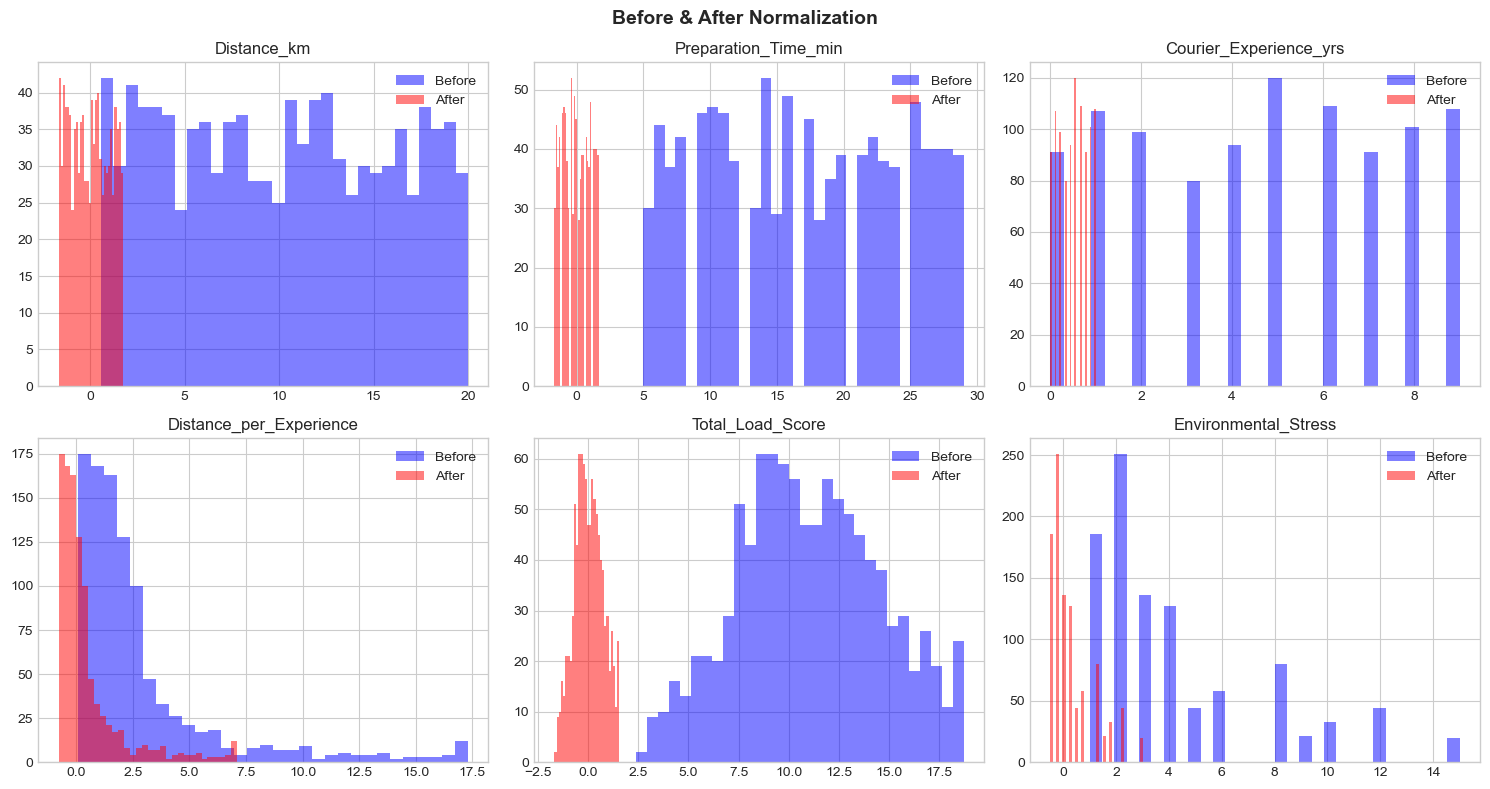

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Distance_km','Preparation_Time_min','Courier_Experience_yrs',
            'Distance_per_Experience','Total_Load_Score','Environmental_Stress']
normalized = ['Distance_km_z','Prep_Time_z','Exp_mm','Dist_Exp_r','Load_r','Env_r']

for i, (orig, norm) in enumerate(zip(features, normalized)):
    row, col = i//3, i%3
    axes[row, col].hist(df[orig], bins=30, alpha=0.5, label='Before', color='blue')
    axes[row, col].hist(df[norm], bins=30, alpha=0.5, label='After', color='red')
    axes[row, col].set_title(orig)
    axes[row, col].legend()

plt.suptitle('Before & After Normalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Normalization_Comparison.png', dpi=300)
plt.show()

In [7]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_train_60, X_temp, y_train_60, y_temp = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)
X_val_20, X_test_20, y_val_20, y_test_20 = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"70:30 -> Train: {len(X_train_70)}, Test: {len(X_test_30)}")
print(f"60:20:20 -> Train: {len(X_train_60)}, Val: {len(X_val_20)}, Test: {len(X_test_20)}")

70:30 -> Train: 700, Test: 300
60:20:20 -> Train: 600, Val: 200, Test: 200


In [8]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=12),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_split=15),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=2000, random_state=42, early_stopping=True, alpha=0.001),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, max_depth=4, n_estimators=150),
    'SVM': SVC(probability=True, random_state=42, kernel='rbf', C=1.5),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000, C=1.0, class_weight='balanced')
}
print("7 models initialized.")

7 models initialized.


In [9]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:,1] if hasattr(model, 'predict_proba') else None
    return {
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1 Score': f1_score(y_te, pred),
        'F2 Score': fbeta_score(y_te, pred, beta=2),
        'ROC AUC': roc_auc_score(y_te, prob) if prob is not None else np.nan
    }, pred, prob


70:30 SPLIT RESULTS
KNN                  | Acc: 0.8733 | AUC: 0.9235
Random Forest        | Acc: 0.8767 | AUC: 0.9407
Decision Tree        | Acc: 0.8700 | AUC: 0.9090
Neural Network       | Acc: 0.8600 | AUC: 0.9363
Gradient Boosting    | Acc: 0.8700 | AUC: 0.9334
SVM                  | Acc: 0.8800 | AUC: 0.9470
Logistic Regression  | Acc: 0.8767 | AUC: 0.9461

                      Accuracy  Precision  Recall  F1 Score  F2 Score  ROC AUC
KNN                    0.8733     0.8707  0.8145    0.8417    0.8252   0.9235
Random Forest          0.8767     0.8480  0.8548    0.8514    0.8535   0.9407
Decision Tree          0.8700     0.8512  0.8306    0.8408    0.8347   0.9090
Neural Network         0.8600     0.8361  0.8226    0.8293    0.8252   0.9363
Gradient Boosting      0.8700     0.8455  0.8387    0.8421    0.8401   0.9334
SVM                    0.8800     0.8492  0.8629    0.8560    0.8601   0.9470
Logistic Regression    0.8767     0.8372  0.8710    0.8538    0.8640   0.9461


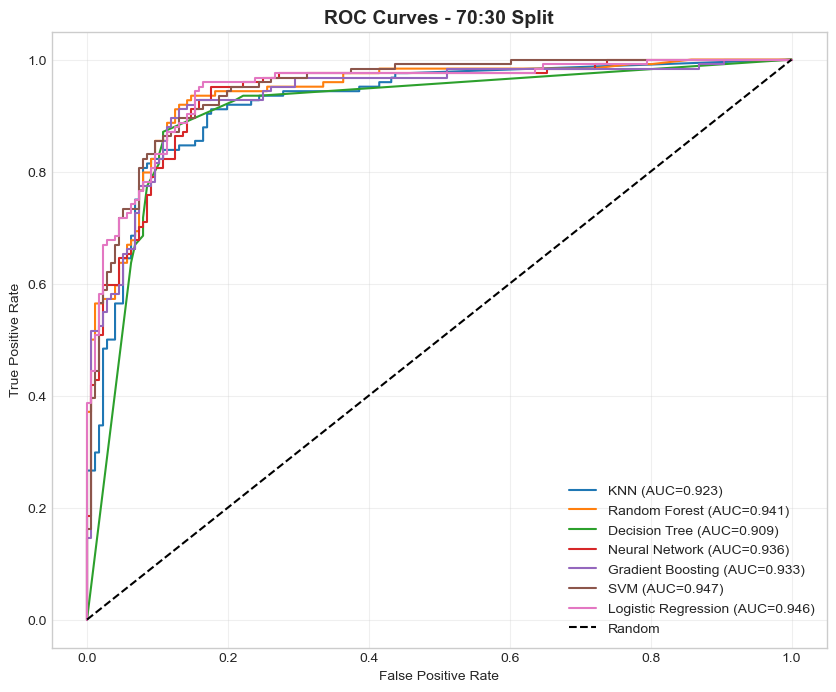

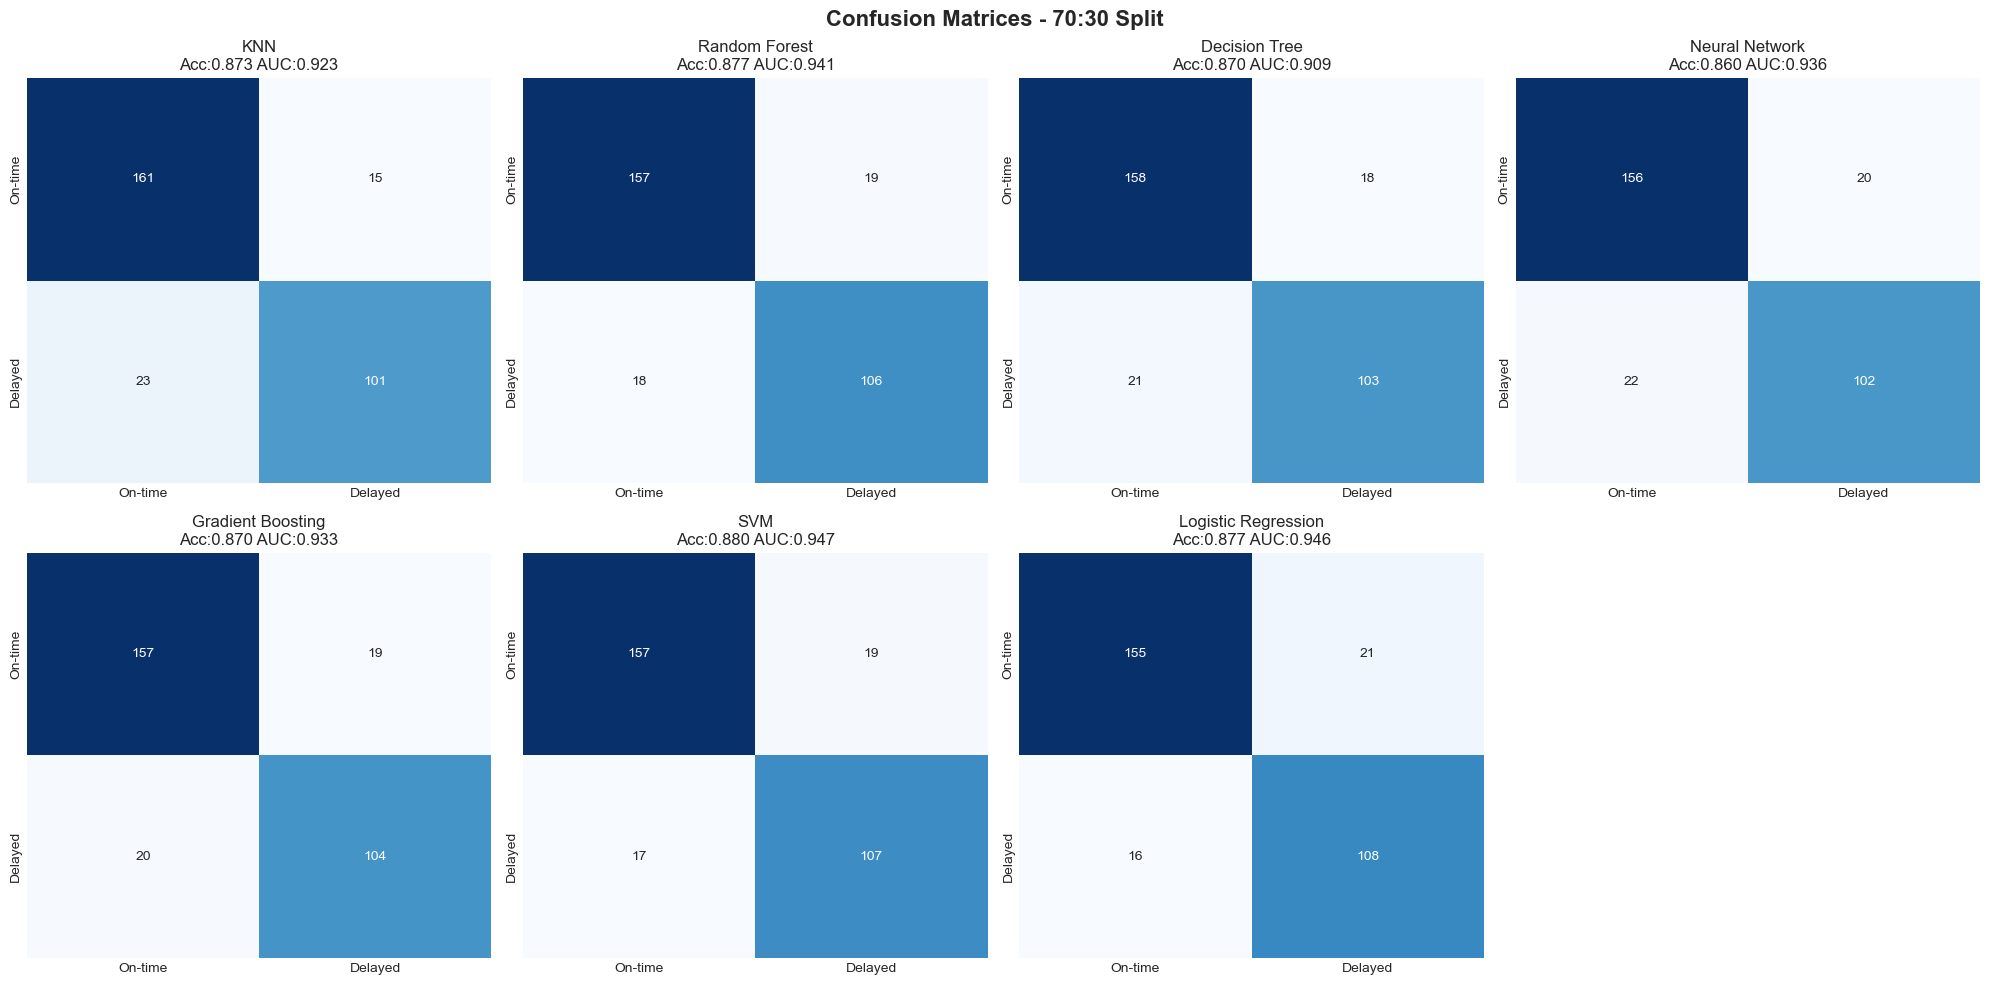

In [10]:
print("\n" + "="*60)
print("70:30 SPLIT RESULTS")
print("="*60)
results_70 = {}
probs_70 = {}
preds_70 = {}
for name, model in models.items():
    metrics, pred, prob = evaluate(model, X_train_70, y_train_70, X_test_30, y_test_30)
    results_70[name] = metrics
    probs_70[name] = prob
    preds_70[name] = pred
    print(f"{name:20s} | Acc: {metrics['Accuracy']:.4f} | AUC: {metrics['ROC AUC']:.4f}")

print("\n", pd.DataFrame(results_70).T.round(4))

# ROC Curves
plt.figure(figsize=(10,8))
for name in models.keys():
    if probs_70[name] is not None:
        fpr, tpr, _ = roc_curve(y_test_30, probs_70[name])
        plt.plot(fpr, tpr, label=f"{name} (AUC={results_70[name]['ROC AUC']:.3f})")
plt.plot([0,1],[0,1],'k--',label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - 70:30 Split', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('ROC_70_30.png', dpi=300)
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.ravel()
for idx, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test_30, preds_70[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['On-time','Delayed'], yticklabels=['On-time','Delayed'])
    axes[idx].set_title(f"{name}\nAcc:{results_70[name]['Accuracy']:.3f} AUC:{results_70[name]['ROC AUC']:.3f}")
axes[7].axis('off')
plt.suptitle('Confusion Matrices - 70:30 Split', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('CM_70_30.png', dpi=300)
plt.show()

In [11]:
print("\n" + "="*60)
print("60:20:20 SPLIT RESULTS")
print("="*60)
results_60 = {}
for name, model in models.items():
    model.fit(X_train_60, y_train_60)
    val_pred = model.predict(X_val_20)
    val_prob = model.predict_proba(X_val_20)[:,1]
    test_pred = model.predict(X_test_20)
    test_prob = model.predict_proba(X_test_20)[:,1]
    results_60[name] = {
        'val': {
            'Accuracy': accuracy_score(y_val_20, val_pred),
            'Precision': precision_score(y_val_20, val_pred),
            'Recall': recall_score(y_val_20, val_pred),
            'F1 Score': f1_score(y_val_20, val_pred),
            'ROC AUC': roc_auc_score(y_val_20, val_prob)
        },
        'test': {
            'Accuracy': accuracy_score(y_test_20, test_pred),
            'Precision': precision_score(y_test_20, test_pred),
            'Recall': recall_score(y_test_20, test_pred),
            'F1 Score': f1_score(y_test_20, test_pred),
            'ROC AUC': roc_auc_score(y_test_20, test_prob)
        }
    }
    print(f"{name:20s} | Val AUC: {results_60[name]['val']['ROC AUC']:.4f} | Test AUC: {results_60[name]['test']['ROC AUC']:.4f}")

print("\nValidation Set:")
print(pd.DataFrame({k:v['val'] for k,v in results_60.items()}).T[['Accuracy','Precision','Recall','F1 Score','ROC AUC']].round(4))
print("\nTest Set:")
print(pd.DataFrame({k:v['test'] for k,v in results_60.items()}).T[['Accuracy','Precision','Recall','F1 Score','ROC AUC']].round(4))


60:20:20 SPLIT RESULTS
KNN                  | Val AUC: 0.9061 | Test AUC: 0.9218
Random Forest        | Val AUC: 0.9417 | Test AUC: 0.9493
Decision Tree        | Val AUC: 0.8923 | Test AUC: 0.8534
Neural Network       | Val AUC: 0.9336 | Test AUC: 0.9397
Gradient Boosting    | Val AUC: 0.9231 | Test AUC: 0.9382
SVM                  | Val AUC: 0.9452 | Test AUC: 0.9523
Logistic Regression  | Val AUC: 0.9460 | Test AUC: 0.9519

Validation Set:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
KNN                     0.860     0.8481  0.8072    0.8272   0.9061
Random Forest           0.895     0.8974  0.8434    0.8696   0.9417
Decision Tree           0.805     0.8056  0.6988    0.7484   0.8923
Neural Network          0.880     0.8642  0.8434    0.8537   0.9336
Gradient Boosting       0.880     0.8642  0.8434    0.8537   0.9231
SVM                     0.895     0.8780  0.8675    0.8727   0.9452
Logistic Regression     0.895     0.8605  0.8916    0.8757   0.9460

Test Set

In [ ]:
print("\n" + "="*60)
print("5-FOLD CROSS VALIDATION")
print("="*60)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, model in models.items():
    auc_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    acc_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_results[name] = {
        'Accuracy': acc_scores.mean(),
        'Acc_Std': acc_scores.std(),
        'ROC AUC': auc_scores.mean(),
        'AUC_Std': auc_scores.std()
    }
    print(f"{name:20s} | AUC: {auc_scores.mean():.4f}±{auc_scores.std():.4f} | Acc: {acc_scores.mean():.4f}±{acc_scores.std():.4f}")

print("\n", pd.DataFrame(cv_results).T.round(4))


5-FOLD CROSS VALIDATION
KNN                  | AUC: 0.9260±0.0104 | Acc: 0.8540±0.0086
